# 01g — Full-vocabulary sweep: largest activation values at each layer, each position

**Goal (Dr. Liu's request):** *"check the largest values at each layer at each token position for all the possible tokens."*

**Interpretation:** sweep the token identity at position 0 across the full vocabulary; report the resulting largest activation value at every layer **and every position downstream** (position 0 is where identity is free to vary — later positions are read out, not independently swept).

**Design:**
- For every token id `t` in the vocabulary, build the input `[t] + SUFFIX_IDS` (fixed neutral suffix, configurable, may be empty).
- One forward pass per input (batched), `output_hidden_states=True` -> 33 hidden states (embedding output + 32 blocks).
- Record, per `(token, layer, position)` — **scalars only**, not full activation vectors:
  1. `max_abs`  — max |activation| over all 4096 channels
  2. `argmax_ch` — which channel attains it
  3. `ma_788`, `ma_1384`, `ma_4062` — signed activation values at the known massive-activation channels
- **No BOS**: tokenized with `add_special_tokens=False`, asserted.
- **All outputs are CSV** (no `.npy`): embedding norms, embedding singular values, and the full `token x layer x position` results table. The results table is long-format (one row per token/layer/position combo) so it stays a single flat, appendable, resumable file — roughly 25.4M rows, ~1.5 GB, nowhere near the ~900 GB it would take to store full activation vectors (that's what the separate `01g-v2` notebook is for, and only for a handful of tokens of interest).
- Correctness gates (Section 3) must all pass before launching the full sweep (Section 4).

## 0. Config

In [ ]:
import os, math, json, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_PATH = "/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct"
DEVICE = "cuda"
DTYPE  = torch.bfloat16          # forward-pass dtype; reductions cast to fp32

# Fixed neutral suffix appended after the swept token, so "each token position"
# is meaningful. Set to "" for pure single-token inputs (positions collapse to 1).
SUFFIX_TEXT = "."

BATCH_SIZE  = 1
MA_CHANNELS = [788, 1384, 4062]  # known massive-activation channels, LLaMA3-8B (Sun et al.)

OUT_DIR = "./01g_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
RESULTS_CSV = f"{OUT_DIR}/vocab_sweep_results.csv"   # long format: one row per token x layer x position
NORMS_CSV   = f"{OUT_DIR}/embedding_norms.csv"
SVALS_CSV   = f"{OUT_DIR}/embedding_singular_values.csv"
STATE_JSON  = f"{OUT_DIR}/sweep_state.json"          # small control-state file, not data
CKPT_EVERY  = 25   # flush/log every N batches

torch.set_grad_enabled(False)
print(torch.__version__, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

2.2.2+cu121 NVIDIA RTX A6000


## 1. Load model & tokenizer

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH, torch_dtype=DTYPE, device_map=DEVICE,
    attn_implementation="eager",
)
model.eval()

VOCAB    = model.config.vocab_size          # 128256
D_MODEL  = model.config.hidden_size         # 4096
N_LAYERS = model.config.num_hidden_layers   # 32
N_HS = N_LAYERS + 1                         # 33: embedding output (0) + 32 blocks
print(f"vocab={VOCAB}  d_model={D_MODEL}  layers={N_LAYERS}  hidden_states={N_HS}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

vocab=128256  d_model=4096  layers=32  hidden_states=33


#### Checking Effects of RoPE

In [ ]:
ids = torch.tensor([[791, 791, 791]], device=DEVICE)  # same token, 3 positions
out = model(input_ids=ids, output_hidden_states=True, use_cache=False)
# print(type(out.hidden_states), len(out.hidden_states), out.hidden_states[0].shape)
h0 = out.hidden_states[0][0]  # (3, 4096)
print((h0[0] - h0[1])) #.abs().max())  # should be exactly 0.0
print((h0[0] - h0[2])) #.abs().max())  # should be exactly 0.0


ids = torch.tensor([[791, 108294, 791]], device=DEVICE)  # token 791 at position 0 AND position 2
out = model(input_ids=ids, output_hidden_states=True, use_cache=False)
h = out.hidden_states[2][0]  # after 2 blocks, say
print((h[0] - h[1])) #.abs().max())
print((h[0] - h[2])) #.abs().max())

In [ ]:
SUFFIX_IDS = tokenizer(SUFFIX_TEXT, add_special_tokens=False)["input_ids"] if SUFFIX_TEXT else []
SEQ_LEN = 1 + len(SUFFIX_IDS)

bos_id = tokenizer.bos_token_id
assert bos_id not in SUFFIX_IDS, "BOS found in suffix — check tokenizer settings"
probe = tokenizer("hello", add_special_tokens=False)["input_ids"]
assert probe[0] != bos_id, "Tokenizer is prepending BOS despite add_special_tokens=False"
print(f"SUFFIX_IDS={SUFFIX_IDS}  ->  '{tokenizer.decode(SUFFIX_IDS)}'  |  SEQ_LEN={SEQ_LEN}")

est_rows = VOCAB * N_HS * SEQ_LEN
print(f"Projected results CSV: {est_rows:,} rows  (~{est_rows*60/1e9:.2f} GB at ~60 bytes/row)")

## 2. Embedding norms & spectrum -> CSV
Reproduce Dr. Liu's two plots as a correctness cross-check, saved as CSV this time instead of `.npy`.

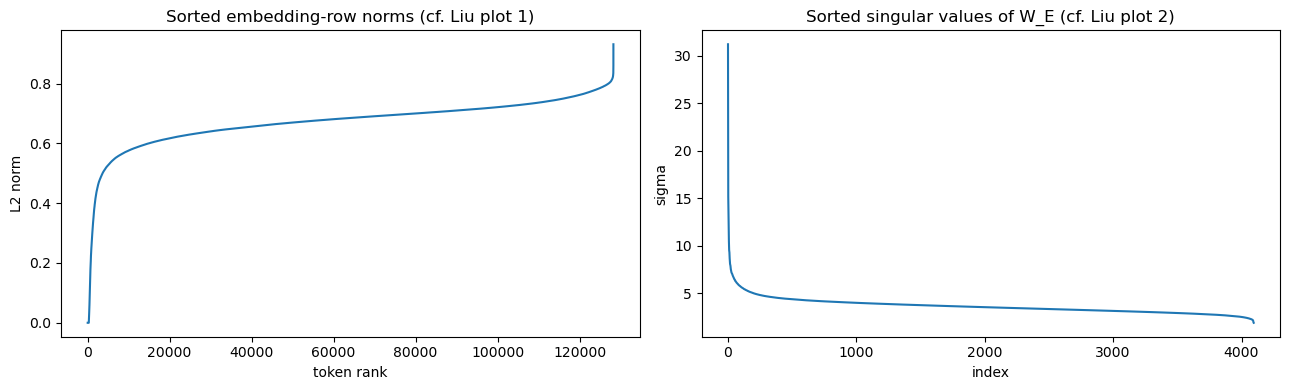

norm range: [0.0000, 0.9313]   sigma1=31.24  sigma50=6.50  sigma_last=1.89
saved -> ./01g_outputs/embedding_norms.csv, ./01g_outputs/embedding_singular_values.csv


In [8]:
W_E = model.get_input_embeddings().weight.detach().float().cpu()   # (V, 4096) fp32 copy
emb_norms = W_E.norm(dim=1).numpy()
pd.DataFrame({"token_id": np.arange(VOCAB), "norm": emb_norms}).to_csv(NORMS_CSV, index=False)

# Thin SVD via the small Gram matrix (4096x4096) — cheap, exact for singular values
G = W_E.T @ W_E
evals = torch.linalg.eigvalsh(G).flip(0).clamp(min=0)
svals = evals.sqrt().numpy()
pd.DataFrame({"index": np.arange(len(svals)), "sigma": svals}).to_csv(SVALS_CSV, index=False)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(np.sort(emb_norms))
ax[0].set_title("Sorted embedding-row norms (cf. Liu plot 1)"); ax[0].set_xlabel("token rank"); ax[0].set_ylabel("L2 norm")
ax[1].plot(svals)
ax[1].set_title("Sorted singular values of W_E (cf. Liu plot 2)"); ax[1].set_xlabel("index"); ax[1].set_ylabel("sigma")
plt.tight_layout(); plt.show()
print(f"norm range: [{emb_norms.min():.4f}, {emb_norms.max():.4f}]   sigma1={svals[0]:.2f}  sigma50={svals[49]:.2f}  sigma_last={svals[-1]:.2f}")
print(f"saved -> {NORMS_CSV}, {SVALS_CSV}")

## 2a. Randomoized vector

In [12]:
def perturb_embedding_random_direction(embedding_row, generator):
    """embedding_row: [d_model] tensor. Returns a new tensor with same norm, random direction."""
    d = embedding_row.shape[0]
    noise = torch.randn(d, generator=generator, device=embedding_row.device, dtype=torch.float32)
    unit_noise = noise / noise.norm()
    new_row = unit_noise * embedding_row.float().norm()

    assert torch.allclose(
        new_row.norm(), embedding_row.float().norm(), rtol=1e-5, atol=1e-6
    ), f"norm mismatch: new={new_row.norm().item():.6f}, orig={embedding_row.float().norm().item():.6f}"

    return new_row.to(embedding_row.dtype)


def build_inputs_embeds_with_perturbation(input_ids, perturb_position, torch_gen):
    """Return inputs_embeds [1, seq, d_model] with the token at perturb_position replaced
    by a random-direction, same-norm embedding."""
    embed_layer = model.get_input_embeddings()
    with torch.no_grad():
        base_embeds = embed_layer(input_ids).clone()  # [1, seq, d_model]
        original_row = base_embeds[0, perturb_position, :]
        perturbed_row = perturb_embedding_random_direction(original_row, torch_gen)
        base_embeds[0, perturb_position, :] = perturbed_row
    return base_embeds


def build_inputs_embeds_no_perturbation(input_ids):
    """Return inputs_embeds [1, seq, d_model] with the token at perturb_position replaced
    by a random-direction, same-norm embedding."""
    embed_layer = model.get_input_embeddings()
    with torch.no_grad():
        base_embeds = embed_layer(input_ids).clone()  # [1, seq, d_model]
    return base_embeds


import random
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


torch_gen = torch.Generator(device=DEVICE)
torch_gen.manual_seed(SEED)

In [13]:
# Representative embedding norm: median over the full vocabulary's row norms.
# The specific token/vector attaining it is irrelevant — this is just a robust
# (outlier-resistant) scalar summary of "how big is a typical embedding vector".
embedding_matrix = model.get_input_embeddings().weight.detach().float()
embedding_row_norms = embedding_matrix.norm(dim=1)  # [VOCAB_SIZE]
median_embedding_norm = embedding_row_norms.median().item()

print(f"Embedding row norms — min={embedding_row_norms.min().item():.4f}  "
      f"median={median_embedding_norm:.4f}  max={embedding_row_norms.max().item():.4f}")


Embedding row norms — min=0.0000  median=0.6849  max=0.9313


In [ ]:
for i, ids in enumerate(samples):
    input_ids = torch.tensor([ids], device=DEVICE)
    inputs_embeds = build_inputs_embeds_no_perturbation(input_ids)
    hidden_states = run_forward(inputs_embeds=inputs_embeds)


start_batch = 0
if os.path.exists(STATE_JSON):
    with open(STATE_JSON) as f: start_batch = json.load(f)["next_batch"]
    print(f"Resuming from batch {start_batch}")
write_header = not os.path.exists(RESULTS_CSV)

n_batches = math.ceil(VOCAB / BATCH_SIZE)
t_start = time.time()
layer_idx = np.arange(N_HS)
pos_idx = np.arange(SEQ_LEN)

for b in range(start_batch, n_batches):
    lo, hi = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, VOCAB)
    chunk = torch.arange(lo, hi)
    max_abs, argmax_ch, ma_vals = run_token_batch(chunk)   # (B,N_HS,T), (B,N_HS,T), (B,N_HS,T,3)

    tok_g, layer_g, pos_g = np.meshgrid(chunk.numpy(), layer_idx, pos_idx, indexing="ij")
    df = pd.DataFrame({
        "token_id":  tok_g.ravel().astype(np.int32),
        "layer":     layer_g.ravel().astype(np.int8),
        "position":  pos_g.ravel().astype(np.int8),
        "max_abs":   max_abs.numpy().ravel().astype(np.float32),
        "argmax_ch": argmax_ch.numpy().ravel().astype(np.int16),
        # "ma_788":    ma_vals[..., 0].numpy().ravel().astype(np.float32),
        # "ma_1384":   ma_vals[..., 1].numpy().ravel().astype(np.float32),
        # "ma_4062":   ma_vals[..., 2].numpy().ravel().astype(np.float32),
    })
    df.to_csv(RESULTS_CSV, mode="a", header=write_header, index=False)
    write_header = False

    if (b + 1) % CKPT_EVERY == 0 or b == n_batches - 1:
        with open(STATE_JSON, "w") as f: json.dump({"next_batch": b + 1}, f)
        el = time.time() - t_start
        print(f"batch {b+1}/{n_batches}  elapsed {el/60:.1f}m  eta {el/(b+1-start_batch)*(n_batches-b-1)/60:.1f}m")

print(f"Sweep complete. Results -> {RESULTS_CSV}")

## 3. Sweep infrastructure + correctness gates
All three gates must pass before Section 4 is launched.

In [ ]:
ma_idx = torch.tensor(MA_CHANNELS, device=DEVICE)
suffix_t = torch.tensor(SUFFIX_IDS, dtype=torch.long, device=DEVICE)

def run_token_batch(token_ids):
    """token_ids: 1-D LongTensor (B,) of swept first tokens.
    Returns (max_abs, argmax_ch, ma_vals) as CPU tensors:
      max_abs   (B, N_HS, SEQ_LEN) fp32
      argmax_ch (B, N_HS, SEQ_LEN) int64
      ma_vals   (B, N_HS, SEQ_LEN, len(MA_CHANNELS)) fp32
    """
    B = token_ids.shape[0]
    ids = torch.empty((B, SEQ_LEN), dtype=torch.long, device=DEVICE)
    ids[:, 0] = token_ids.to(DEVICE)
    if SEQ_LEN > 1:
        ids[:, 1:] = suffix_t.unsqueeze(0)
    out = model(input_ids=ids, output_hidden_states=True, use_cache=False)
    hs = torch.stack(out.hidden_states, dim=1).float()   # (B, N_HS, T, D) fp32
    abs_hs = hs.abs()
    max_abs, argmax_ch = abs_hs.max(dim=-1)               # (B, N_HS, T)
    ma_vals = hs.index_select(-1, ma_idx)                 # (B, N_HS, T, 3) signed values
    return max_abs.cpu(), argmax_ch.cpu(), ma_vals.cpu()

In [ ]:
# --- Gate 1: batch-vs-single consistency -------------------------------------
# Tolerance is looser than a typical numerical-equality check: token 128000 is
# <|begin_of_text|>, which at position 0 triggers a massive activation spike
# (~2000-2500x median, see Gate 2). At that magnitude, bf16 batched-matmul
# kernels use a different reduction order than the single-sample kernel, so a
# ~1e-3 relative disagreement on the massive-activation channels is expected
# numerical noise, not a correctness bug. Non-spiking tokens agree far tighter.
test_ids = torch.tensor([128000, 791, 40, 15339, 100000])
m_b, a_b, v_b = run_token_batch(test_ids)
for i, t in enumerate(test_ids):
    m_s, a_s, v_s = run_token_batch(t.unsqueeze(0))
    rel = (m_b[i] - m_s[0]).abs().max() / m_s[0].abs().max()
    assert rel < 5e-3, f"batch/single mismatch for token {t}: rel={rel:.2e}"
print("Gate 1 PASS — batching does not change results (rel err < 5e-3)")

In [ ]:
# --- Gate 2: massive-activation sanity on a known-behavior prompt ------------
prompt_ids = torch.tensor(tokenizer("Tell me how to make a cake.", add_special_tokens=False)["input_ids"], device=DEVICE).unsqueeze(0)
out = model(input_ids=prompt_ids, output_hidden_states=True, use_cache=False)
hs = torch.stack(out.hidden_states, dim=1).float()[0]        # (N_HS, T, D)
median_abs = hs.abs().median(dim=-1).values
max_abs_g2 = hs.abs().max(dim=-1).values
ratio = (max_abs_g2 / median_abs.clamp(min=1e-6))
print("pos-0 max/median ratio by layer (expect >1000x at some mid layer):")
print(np.round(ratio[:, 0].cpu().numpy(), 1))
print("last-pos max/median ratio by layer (expect modest, ~O(10x)):")
print(np.round(ratio[:, -1].cpu().numpy(), 1))

In [ ]:
# --- Gate 3: timing estimate before committing -------------------------------
t0 = time.time(); _ = run_token_batch(torch.arange(BATCH_SIZE)); torch.cuda.synchronize()
per_batch = time.time() - t0
n_batches = math.ceil(VOCAB / BATCH_SIZE)
print(f"Gate 3 — {per_batch:.2f}s/batch x {n_batches} batches ~ {per_batch*n_batches/60:.1f} min total (forward-pass time only)")

## 4. Full-vocabulary sweep -> CSV (resumable)
Writes one long-format CSV (`vocab_sweep_results.csv`, columns: `token_id, layer, position, max_abs, argmax_ch, ma_788, ma_1384, ma_4062`), appended batch by batch. Resumes by tracking `next_batch` in a small state file — the CSV itself is never re-read or rewritten, only appended to, so restarting is cheap regardless of how large the file has grown.

In [ ]:
start_batch = 0
if os.path.exists(STATE_JSON):
    with open(STATE_JSON) as f: start_batch = json.load(f)["next_batch"]
    print(f"Resuming from batch {start_batch}")
write_header = not os.path.exists(RESULTS_CSV)

n_batches = math.ceil(VOCAB / BATCH_SIZE)
t_start = time.time()
layer_idx = np.arange(N_HS)
pos_idx = np.arange(SEQ_LEN)

for b in range(start_batch, n_batches):
    lo, hi = b * BATCH_SIZE, min((b + 1) * BATCH_SIZE, VOCAB)
    chunk = torch.arange(lo, hi)
    max_abs, argmax_ch, ma_vals = run_token_batch(chunk)   # (B,N_HS,T), (B,N_HS,T), (B,N_HS,T,3)

    tok_g, layer_g, pos_g = np.meshgrid(chunk.numpy(), layer_idx, pos_idx, indexing="ij")
    df = pd.DataFrame({
        "token_id":  tok_g.ravel().astype(np.int32),
        "layer":     layer_g.ravel().astype(np.int8),
        "position":  pos_g.ravel().astype(np.int8),
        "max_abs":   max_abs.numpy().ravel().astype(np.float32),
        "argmax_ch": argmax_ch.numpy().ravel().astype(np.int16),
        "ma_788":    ma_vals[..., 0].numpy().ravel().astype(np.float32),
        "ma_1384":   ma_vals[..., 1].numpy().ravel().astype(np.float32),
        "ma_4062":   ma_vals[..., 2].numpy().ravel().astype(np.float32),
    })
    df.to_csv(RESULTS_CSV, mode="a", header=write_header, index=False)
    write_header = False

    if (b + 1) % CKPT_EVERY == 0 or b == n_batches - 1:
        with open(STATE_JSON, "w") as f: json.dump({"next_batch": b + 1}, f)
        el = time.time() - t_start
        print(f"batch {b+1}/{n_batches}  elapsed {el/60:.1f}m  eta {el/(b+1-start_batch)*(n_batches-b-1)/60:.1f}m")

print(f"Sweep complete. Results -> {RESULTS_CSV}")

## 5. Analysis
### 5.0 Load results

In [ ]:
dtype_map = {"token_id": "int32", "layer": "int16", "position": "int16",
             "max_abs": "float32", "argmax_ch": "int32",
             "ma_788": "float32", "ma_1384": "float32", "ma_4062": "float32"}
df = pd.read_csv(RESULTS_CSV, dtype=dtype_map)
norms_df = pd.read_csv(NORMS_CSV).set_index("token_id")["norm"]
svals_df = pd.read_csv(SVALS_CSV)
print(f"loaded {len(df):,} rows, {df.memory_usage(deep=True).sum()/1e9:.2f} GB in memory")

### 5.1 How much do the largest values vary across first tokens? (Liu's core prediction)

In [ ]:
pos0 = df[df.position == 0]
peak_idx = pos0.groupby("token_id")["max_abs"].idxmax()
peak_tbl = pos0.loc[peak_idx, ["token_id", "layer", "max_abs"]].set_index("token_id").sort_index()
peak_per_token = peak_tbl["max_abs"]
peak_layer = peak_tbl["layer"]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(peak_per_token, bins=200, log=True)
ax[0].set_title("Distribution of peak |activation| at position 0, per first token")
ax[0].set_xlabel("peak max-abs (over layers)"); ax[0].set_ylabel("token count (log)")
ax[1].hist(peak_layer, bins=N_HS)
ax[1].set_title("Which layer attains the peak"); ax[1].set_xlabel("layer index")
plt.tight_layout(); plt.show()
print(f"peak spread: min={peak_per_token.min():.1f}  median={peak_per_token.median():.1f}  max={peak_per_token.max():.1f}  (max/median = {peak_per_token.max()/peak_per_token.median():.1f}x)")

### 5.2 Correlation with embedding norm (the plot-1 hypothesis)

In [ ]:
from scipy.stats import spearmanr, pearsonr
aligned_norms = norms_df.loc[peak_per_token.index].values
rho_s, _ = spearmanr(aligned_norms, peak_per_token.values)
rho_p, _ = pearsonr(aligned_norms, peak_per_token.values)
plt.figure(figsize=(6.5, 5))
plt.hexbin(aligned_norms, peak_per_token.values, gridsize=80, bins="log")
plt.xlabel("embedding norm of first token"); plt.ylabel("peak |activation| at position 0")
plt.title(f"Spearman={rho_s:.3f}  Pearson={rho_p:.3f}")
plt.colorbar(label="log token count"); plt.show()

### 5.3 Direction vs magnitude: projection onto top singular vectors of W_E

In [ ]:
K = 50
evals2, evecs = torch.linalg.eigh(G)
Vtop = evecs[:, -K:].flip(1)
proj = (W_E @ Vtop)
proj_energy = pd.Series(proj.pow(2).sum(dim=1).sqrt().numpy(), index=np.arange(VOCAB))
aligned_proj = proj_energy.loc[peak_per_token.index].values
rho_dir, _ = spearmanr(aligned_proj, peak_per_token.values)
print(f"Spearman(peak, top-{K}-subspace loading) = {rho_dir:.3f}   vs   Spearman(peak, raw norm) = {rho_s:.3f}")

### 5.4 Position dependence + extreme tokens

In [ ]:
if SEQ_LEN > 1:
    for pos in range(SEQ_LEN):
        sub = df[df.position == pos]
        pk = sub.groupby("token_id")["max_abs"].max().reindex(peak_per_token.index)
        r, _ = spearmanr(aligned_norms, pk.values)
        print(f"position {pos}: peak spread {pk.max()/pk.median():8.1f}x   Spearman vs first-token norm = {r:+.3f}")

order = peak_per_token.sort_values()
print("\nTop-15 first tokens by peak activation:")
for t in order.index[-15:][::-1]:
    row = pos0[(pos0.token_id == t) & (pos0.layer == peak_layer.loc[t])].iloc[0]
    print(f"  id={t:6d}  peak={peak_per_token.loc[t]:9.1f}  layer={peak_layer.loc[t]:2d}  ch={int(row.argmax_ch):4d}  norm={norms_df.loc[t]:.3f}  tok={tokenizer.decode([int(t)])!r}")
print("\nBottom-5:")
for t in order.index[:5]:
    print(f"  id={t:6d}  peak={peak_per_token.loc[t]:9.1f}  norm={norms_df.loc[t]:.3f}  tok={tokenizer.decode([int(t)])!r}")

In [ ]:
# How often is the argmax channel one of the known MA channels, per layer (position 0)?
for L in sorted(pos0.layer.unique()):
    sub = pos0[pos0.layer == L]
    frac = sub.argmax_ch.isin(MA_CHANNELS).mean()
    if frac > 0.01:
        print(f"layer {L:2d}: argmax in {{788,1384,4062}} for {frac*100:5.1f}% of tokens")

### 5.5 Max activation by layer — representative tokens

In [ ]:
# Edit this list to try different tokens — no other code in this cell needs to change.
REPRESENTATIVE_TOKENS = [791, 108294, 128046, 13]
# 791    = ordinary token
# 108294 = highest-peak token from 5.4's top-15
# 128046 = lowest-peak reserved/zero-embedding token from 5.4's bottom-5
# 13     = the suffix token (identical position 0 / position 1 by construction)

sub = df[df.token_id.isin(REPRESENTATIVE_TOKENS) & df.position.isin([0, 1])]

colors = plt.cm.tab10(np.linspace(0, 1, len(REPRESENTATIVE_TOKENS)))
fig, ax = plt.subplots(figsize=(10, 5))
for color, t in zip(colors, REPRESENTATIVE_TOKENS):
    for pos, ls in [(0, "-"), (1, "--")]:
        row = sub[(sub.token_id == t) & (sub.position == pos)].sort_values("layer")
        if row.empty:
            print(f"warning: no rows for token {t}, position {pos} — skipping")
            continue
        ax.plot(row.layer, row.max_abs, color=color, linestyle=ls,
                label=f"id={t} ({tokenizer.decode([t])!r}), pos={pos}")

ax.set_yscale("log")
ax.set_xlabel("layer"); ax.set_ylabel("max |activation|  (log scale)")
ax.set_xticks(range(33))
ax.set_xlim(-0.5, 32.5)
ax.set_title("Max activation by layer — representative tokens (solid=pos 0, dashed=pos 1)")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

## 6. Interpretation notes (fill in after the run)
- Peak spread across tokens (5.1): large spread -> supports Liu's token-identity hypothesis; tight spread -> supports the positional-sink story.
- Correlation sign & strength (5.2 vs 5.3): norm-driven vs direction-driven distinction maps onto hypothesis (1) magnitude vs (2) functional in the DIM-alignment tension.
- Position table (5.4): whether the first token's identity influences later-position max values tells us if the effect is confined to position 0 or propagates.
- Argmax-channel table: whether the vocab-wide max values live on the known MA channels or elsewhere.
- All outputs are CSV under `01g_outputs/`: `vocab_sweep_results.csv` (main long-format results), `embedding_norms.csv`, `embedding_singular_values.csv`.